# Task 4: K-Means on an image

The file `kmeans-image.txt` has one RGB vector per line (one pixel each).
The image is 516 rows by 407 columns. We run our own K-Means with K = 8 and
the initial centroids given in the question, using squared Euclidean distance.

Initial centroids (R, G, B):

| 255 255 255 |
| 255 0 0 |
| 128 0 0 |
| 0 255 0 |
| 0 128 0 |
| 0 0 255 |
| 0 0 128 |
| 0 0 0 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ROWS = 516
COLS = 407

# each line is the R, G, B of one pixel
data = np.loadtxt('kmeans-image.txt')
print('data shape:', data.shape)

# initial centroids given in the question
centroids_init = np.array([
    [255, 255, 255],
    [255,   0,   0],
    [128,   0,   0],
    [  0, 255,   0],
    [  0, 128,   0],
    [  0,   0, 255],
    [  0,   0, 128],
    [  0,   0,   0],
], dtype=float)
K = 8

data shape: (210012, 3)


## K-Means steps

Two helper functions:
- `assign_clusters`: put each pixel with its nearest centroid.
- `update_centroids`: move each centroid to the mean of its pixels.

For the distances we just loop over the K centroids and, for each one,
compute the squared distance from every pixel to that centroid. This is
easier to read than doing it all in one big array operation.

In [2]:
def assign_clusters(data, centroids):
    # For each pixel, find the nearest centroid (squared Euclidean distance).
    n = len(data)
    dist2 = np.zeros((n, K))
    for k in range(K):
        diff = data - centroids[k]
        dist2[:, k] = np.sum(diff ** 2, axis=1)
    return np.argmin(dist2, axis=1)


def update_centroids(data, labels, centroids):
    # Move each centroid to the average of the pixels assigned to it.
    new_centroids = centroids.copy()
    for k in range(K):
        points = data[labels == k]
        if len(points) > 0:
            new_centroids[k] = points.mean(axis=0)
    return new_centroids


def total_error(data, labels, centroids):
    # total squared distance from each pixel to its centroid
    error = 0.0
    for k in range(K):
        points = data[labels == k]
        error += np.sum((points - centroids[k]) ** 2)
    return error

In [3]:
# run K-Means until the assignments stop changing
centroids = centroids_init.copy()
labels = None
it = 0

print('iter | error')
while True:
    it += 1
    new_labels = assign_clusters(data, centroids)
    err = total_error(data, new_labels, centroids)
    print(it, '|', round(err, 2))

    if labels is not None and np.array_equal(new_labels, labels):
        print('Converged after', it, 'iterations.')
        break

    labels = new_labels
    centroids = update_centroids(data, labels, centroids)

iter | error
1 | 1288503836.0
2 | 210294736.58
3 | 174481268.85


4 | 165262491.16
5 | 143531825.45
6 | 130990410.13
7 | 129858375.74


8 | 129706609.79
9 | 129641192.27
10 | 129602608.83
11 | 129576454.11


12 | 129560005.54
13 | 129542171.53
14 | 129527709.15
15 | 129511423.82


16 | 129496626.22
17 | 129480900.19
18 | 129464444.13
19 | 129444160.52


...

30 | 118120296.95
31 | 118001542.67
32 | 117944999.27


33 | 117919337.55
34 | 117905042.94
35 | 117893379.33
36 | 117889008.23


37 | 117887541.06
38 | 117886951.19
39 | 117886642.54
40 | 117886384.86


41 | 117886230.63
42 | 117886120.59
43 | 117886095.23
44 | 117886085.04


45 | 117886072.67
46 | 117886065.4
47 | 117886062.13
48 | 117886061.64
Converged after 48 iterations.


## Final centroids

In [4]:
print('  k        R        G        B     pixels')
for k in range(K):
    r, g, b = centroids[k]
    count = np.sum(labels == k)
    print(f'{k:3d}  {r:7.2f}  {g:7.2f}  {b:7.2f}  {count:9d}')

  k        R        G        B     pixels
  0   241.23   238.63   233.86       4930
  1   194.41   136.33    90.94      15190
  2   136.27    61.09    10.10      52535
  3     0.00   255.00     0.00          0
  4   157.29    97.59    51.43      22075
  5     0.00     0.00   255.00          0
  6    78.93    37.11    13.07      40365
  7    25.98    23.24    23.61      74917


## Show the image with each pixel replaced by its centroid colour

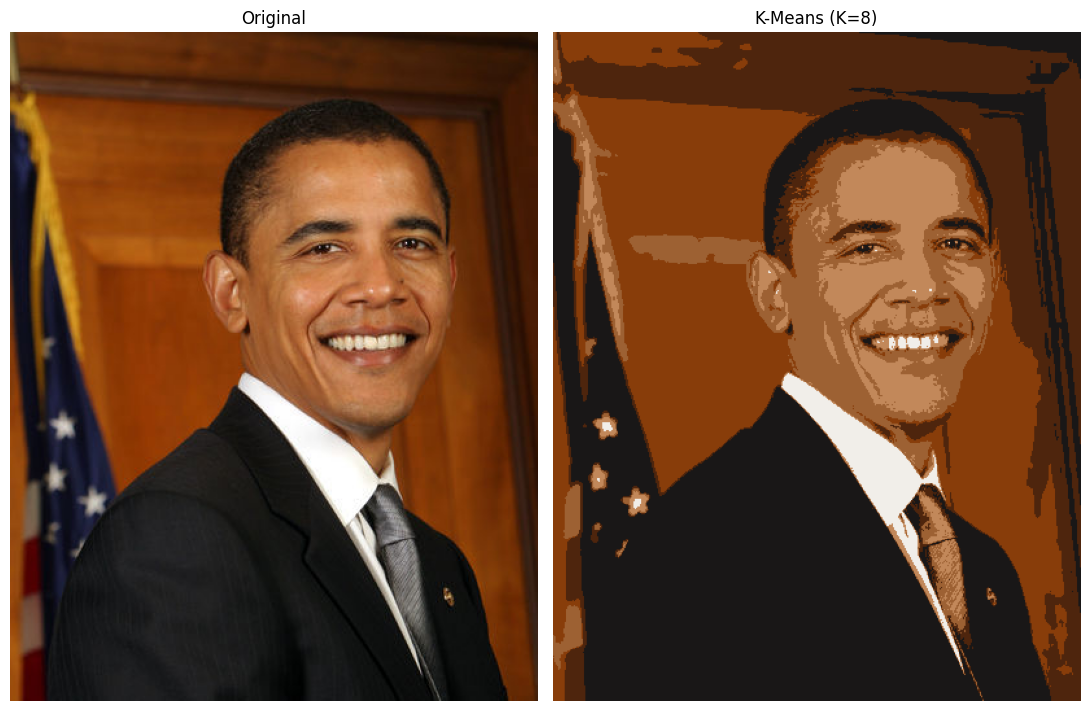

In [5]:
quantised = centroids[labels].reshape(ROWS, COLS, 3).astype(np.uint8)
original = data.reshape(ROWS, COLS, 3).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(11, 7))
ax[0].imshow(original); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(quantised); ax[1].set_title('K-Means (K=8)'); ax[1].axis('off')
plt.tight_layout()
plt.savefig('kmeans_result.png', dpi=120)
plt.show()